# Notebook 01 — Sampling Demo

Generate a synthetic IRM microtubule image from a binary segmentation mask using the DiffuMT diffusion model.

**Works on:** CPU (slow, ~2 min per image), Apple MPS, or CUDA.

**Requirements:** `pip install diffusers transformers accelerate torch torchvision huggingface_hub Pillow matplotlib numpy`

The model is loaded directly from Hugging Face ([HTW-KI-Werkstatt/DiffuMT](https://huggingface.co/HTW-KI-Werkstatt/DiffuMT)); no local checkpoint needed.

In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Load the model from Hugging Face

The diagnostic-selected checkpoint (epoch 290) is hosted at
[HTW-KI-Werkstatt/DiffuMT](https://huggingface.co/HTW-KI-Werkstatt/DiffuMT).
Weights are cached locally after the first download (~455 MB).

In [2]:
from diffusers import UNet2DModel, DDIMScheduler

HF_REPO = "HTW-KI-Werkstatt/DiffuMT"

unet = (
    UNet2DModel.from_pretrained(HF_REPO, subfolder="unet", use_safetensors=True)
    .to(device)
    .eval()
)
scheduler = DDIMScheduler.from_pretrained(HF_REPO, subfolder="scheduler")

print(f"UNet loaded. Parameters: {sum(p.numel() for p in unet.parameters()):,}")
print(f"Scheduler: {scheduler.__class__.__name__}, beta_schedule={scheduler.config.beta_schedule}")

/opt/anaconda3/envs/diffmt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/diffmt/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


UNet loaded. Parameters: 113,674,371
Scheduler: DDIMScheduler, beta_schedule=linear


## 2. Load a conditioning mask

The mask is a binary PNG (foreground = microtubule pixels, 255; background = 0).
Set `mask_path` to your own file, or leave it `None` to use the built-in stripe mask.

**Important:** the model was trained with `ScaleSeg`, which maps pixel values
`{0, 255} → {0, 1/255}` (not `{0, 1}`). The cell below applies this scaling inline.

Using synthetic stripe mask — set mask_path to load your own.


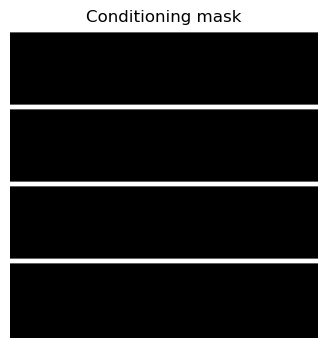

Mask tensor range: [0.000000, 0.003922]  (expected: [0, 0.003922])


In [3]:
IMG_SIZE = 256

# Set to a path like Path("my_mask.png") to use your own binary mask
mask_path = None

if mask_path is not None and Path(mask_path).exists():
    from pathlib import Path
    mask_pil = Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
else:
    # Synthetic stripe mask — stand-in for microtubule foreground
    arr = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    for y in range(0, IMG_SIZE, 64):
        arr[max(0, y - 2):y + 2, :] = 255
    mask_pil = Image.fromarray(arr, mode="L")
    print("Using synthetic stripe mask — set mask_path to load your own.")

# ScaleSeg: ToTensor maps {0,255}→{0,1}; divide by 255 again → {0, 1/255}
seg_tensor = (transforms.ToTensor()(mask_pil) / 255.0).unsqueeze(0).to(device)  # (1, 1, H, W)

plt.figure(figsize=(4, 4))
plt.imshow(mask_pil, cmap="gray")
plt.title("Conditioning mask")
plt.axis("off")
plt.show()
print(f"Mask tensor range: [{seg_tensor.min():.6f}, {seg_tensor.max():.6f}]  (expected: [0, {1/255:.6f}])")

## 3. Run DDIM sampling

We use a deterministic DDIM reverse process (η = 0) conditioned on the mask.
The mask is concatenated with the noisy image as a 4th channel at each step.

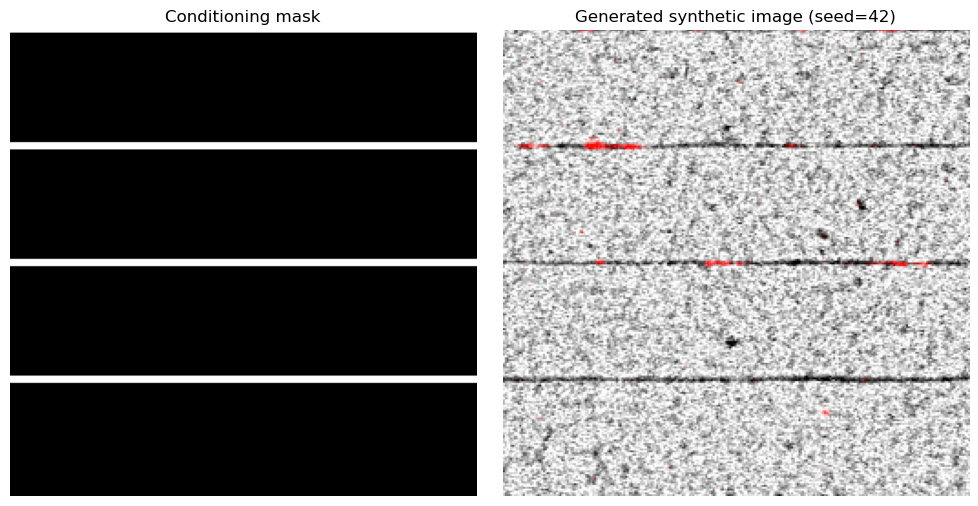

In [4]:
def sample(seg: torch.Tensor, seed: int = 42, steps: int = 50) -> Image.Image:
    """Run DDIM sampling conditioned on seg mask (1, 1, H, W)."""
    scheduler.set_timesteps(steps)
    gen = torch.Generator(device=device).manual_seed(seed)
    x = torch.randn((1, 3, IMG_SIZE, IMG_SIZE), generator=gen, device=device)

    with torch.no_grad():
        for t in scheduler.timesteps:
            x_in = torch.cat([x, seg], dim=1)          # (1, 4, H, W)
            noise_pred = unet(x_in, t).sample
            x = scheduler.step(noise_pred, t, x).prev_sample

    arr = (x / 2 + 0.5).clamp(0, 1)
    arr = (arr[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)


generated = sample(seg_tensor, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_pil, cmap="gray")
axes[0].set_title("Conditioning mask")
axes[0].axis("off")
axes[1].imshow(generated)
axes[1].set_title("Generated synthetic image (seed=42)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Diversity: same mask, different seeds

DDIM (η = 0) is deterministic per seed but stochastic across seeds — each
initial noise vector `x_T` maps to a different image while preserving the mask structure.

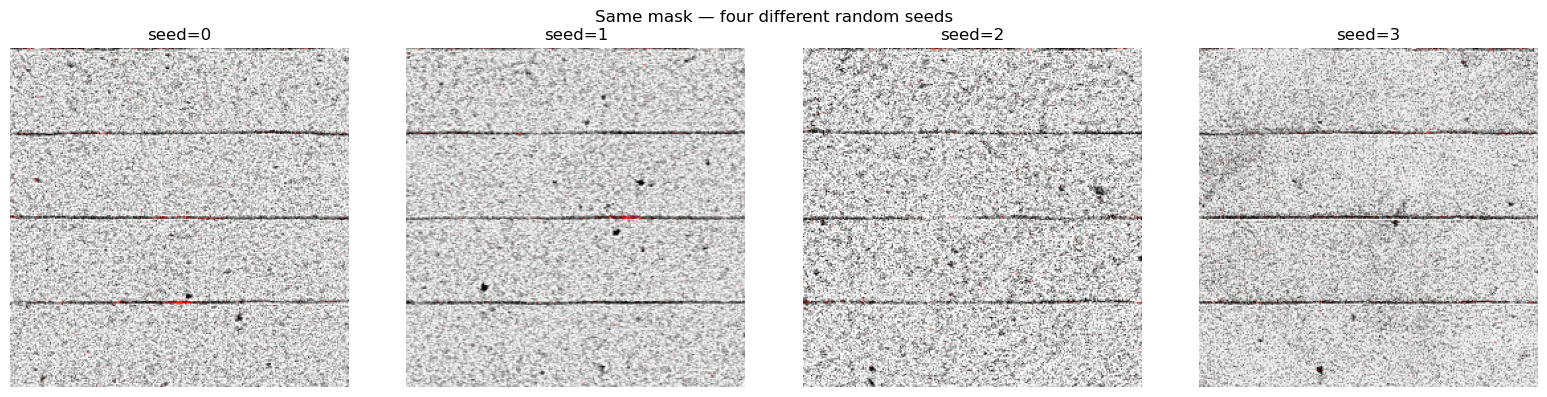

In [5]:
N_SEEDS = 4
samples = [sample(seg_tensor, seed=s) for s in range(N_SEEDS)]

fig, axes = plt.subplots(1, N_SEEDS, figsize=(4 * N_SEEDS, 4))
for ax, img, seed in zip(axes, samples, range(N_SEEDS)):
    ax.imshow(img)
    ax.set_title(f"seed={seed}")
    ax.axis("off")
plt.suptitle("Same mask — four different random seeds")
plt.tight_layout()
plt.show()